# Minimize price variance (risk) in a dual-supplier procurement strategy


This analysis examines the price volatility of two suppliers over a 5-year period (2016-2020) and determines the optimal purchasing mix that minimizes price risk using portfolio theory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("prices.csv")

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
df.set_index('date', inplace=True)

pA = df["price_supplier_a_dollars_per_item"].astype(float)
pB = df["price_supplier_b_dollars_per_item"].astype(float)

df.head()

,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
date,,
2016-02-01,104,76
2016-03-01,108,76
2016-04-01,101,84
2016-05-01,104,79
2016-06-01,102,81


In [2]:
#Optimize variance
muA, muB = pA.mean(), pB.mean()
varA, varB = pA.var(), pB.var()
covAB = np.cov(pA, pB)[0, 1]
omega_values = np.linspace(0, 1, 500)
variance_values = (omega_values ** 2 * varA +
            (1 - omega_values) ** 2 * varB +
            2 * omega_values * (1 - omega_values) * covAB)

optimal_index = np.argmin(variance_values)
optimal_w = omega_values[optimal_index]
optimal_var = variance_values[optimal_index]

expected_cost = optimal_w * muA + (1 - optimal_w) * muB


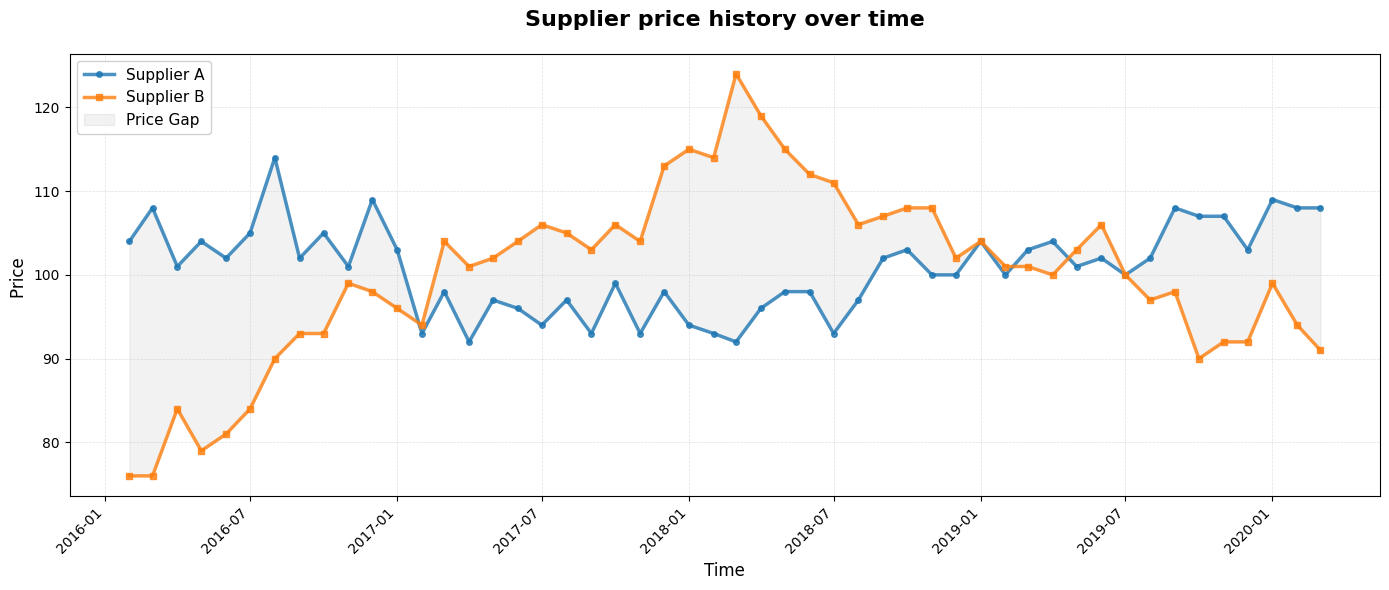

In [3]:
# Figure 1: Supplier prices
fig1, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(pA.index, pA, label="Supplier A", linewidth=2.5,color="#1f77b4", marker='o', markersize=4, alpha=0.8)
ax1.plot(pB.index, pB, label="Supplier B", linewidth=2.5,color="#ff7f0e", marker='s', markersize=4, alpha=0.8)

ax1.fill_between(pA.index, pA, pB, alpha=0.1, color='gray', label='Price Gap')

ax1.set_title("Supplier price history over time", fontsize=16, weight='bold', pad=20)
ax1.set_ylabel("Price ", fontsize=12)
ax1.set_xlabel("Time", fontsize=12)
ax1.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)
ax1.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9)
ax1.tick_params(axis='both', which='major', labelsize=10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


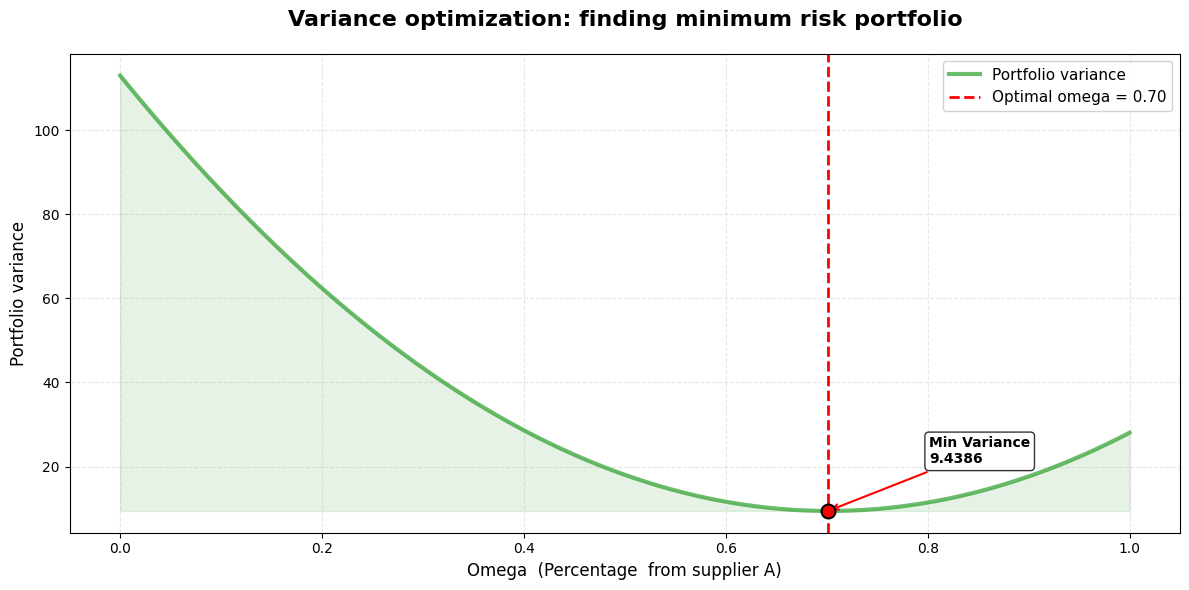

In [4]:
# Figure 2: variance optimization 
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(omega_values, variance_values, linewidth=3, color="#2ca02c",alpha=0.7, label='Portfolio variance')

ax2.axvline(optimal_w, color="red", linestyle="--", linewidth=2,label=f'Optimal omega = {optimal_w:.2f}')
ax2.scatter([optimal_w], [min(variance_values)], color='red', s=100,zorder=5, edgecolors='black', linewidth=1.5)

ax2.set_title("Variance optimization: finding minimum risk portfolio",fontsize=16, weight='bold', pad=20)
ax2.set_xlabel("Omega  (Percentage  from supplier A)", fontsize=12)
ax2.set_ylabel("Portfolio variance", fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11, loc='upper right', frameon=True, framealpha=0.9)
ax2.tick_params(axis='both', which='major', labelsize=10)

ax2.fill_between(omega_values, variance_values, min(variance_values),alpha=0.1, color='green')

ax2.annotate(f'Min Variance\n{min(variance_values):.4f}',xy=(optimal_w, min(variance_values)),
             xytext=(optimal_w + 0.1, min(variance_values) + max(variance_values) * 0.1),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                 fontsize=10, weight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

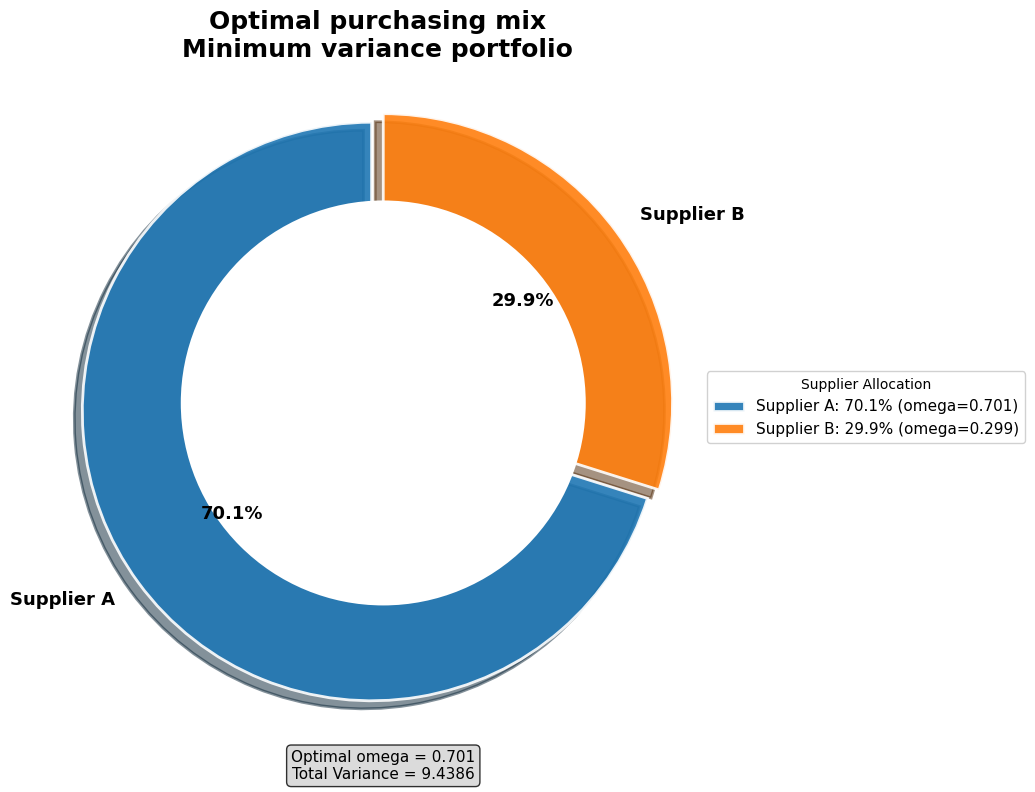

In [5]:
# Figure 3: Pie chart
fig3, ax3 = plt.subplots(figsize=(10, 8))

labels = [f"Supplier A", f"Supplier B"]
sizes = [optimal_w, 1 - optimal_w]
colors = ["#1f77b4", "#ff7f0e"]
explode = (0.05, 0)  
percentages = [optimal_w * 100, (1 - optimal_w) * 100]

wedges,texts,autotexts = ax3.pie(
        sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        shadow=True,
        textprops={'fontsize': 13, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'alpha': 0.9}
    )



centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax3.add_artist(centre_circle)

ax3.axis('equal')

title_text = f"Optimal purchasing mix\nMinimum variance portfolio"
ax3.set_title(title_text, fontsize=18, weight='bold', pad=20)

subtitle = f"Optimal omega = {optimal_w:.3f}\nTotal Variance = {min(variance_values):.4f}"
ax3.text(0, -1.3, subtitle, ha='center', fontsize=11,bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

legend_labels = [f"{label}: {size:.1%} (omega={size:.3f})"
                     for label, size in zip(labels, sizes)]
ax3.legend(wedges, legend_labels, title="Supplier Allocation",
               loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
               fontsize=11, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

### Portfolio Summary

In [6]:
print("Optimization results".center(60))
print("=" * 60)

print(f"{'Metric':<30} {'Value':<30}")
print("-" * 60)
print(f"{'Optimal omega (Supplier A)':<30} {optimal_w:.4f}")
print(f"{'Optimal omega (Supplier B)':<30} {1 - optimal_w:.4f}")
print(f"{'Minimum portfolio variance':<30} {min(variance_values):.6f}")
print(f"{'Supplier A average price':<30} {pA.mean():.2f}")
print(f"{'Supplier B average price':<30} {pB.mean():.2f}")
print(f"{'Supplier A Std Dev':<30} {pA.std():.4f}")
print(f"{'Supplier B Std Dev':<30} {pB.std():.4f}")
print("=" * 60)

                    Optimization results                    
Metric                         Value                         
------------------------------------------------------------
Optimal omega (Supplier A)     0.7014
Optimal omega (Supplier B)     0.2986
Minimum portfolio variance     9.438642
Supplier A average price       100.80
Supplier B average price       100.00
Supplier A Std Dev             5.2954
Supplier B Std Dev             10.6292


## Final decision making

In [7]:
print("==============================")
print(" Optimal purchasing decision")
print("==============================")
print(f"Supplier A average price  : {muA:.2f}")
print(f"Supplier B average price  : {muB:.2f}")
print(f"Supplier A variance       : {varA:.2f}")
print(f"Supplier B variance       : {varB:.2f}")
print(f"Covariance (A,B)          : {covAB:.2f}")

print(f"\nOptimal Supplier A share  : {optimal_w:.2f}")
print(f"Optimal Supplier B share  : {1 - optimal_w:.2f}")
print(f"\nExpected blended cost     : {expected_cost:.2f}")
print(f"Minimum variance achieved : {optimal_var:.4f}")

 Optimal purchasing decision
Supplier A average price  : 100.80
Supplier B average price  : 100.00
Supplier A variance       : 28.04
Supplier B variance       : 112.98
Covariance (A,B)          : -34.45

Optimal Supplier A share  : 0.70
Optimal Supplier B share  : 0.30

Expected blended cost     : 100.56
Minimum variance achieved : 9.4386


# Eng / Yazeed Fahad Alzaidi

## Linkedin : www.linkedin.com/in/yazeed-alzaidi-bb4982298

## Github : EngYazeedFahad